<a href="https://colab.research.google.com/github/Giovanni-Hessel/FIAP-ML-2026/blob/main/Machine_Learning_CP2_%26_AICSS_CP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Importação do dataset
df = pd.read_csv('https://raw.githubusercontent.com/Giovanni-Hessel/FIAP-ML-2026/refs/heads/main/SafeForge_Sensor_Logs.CSV', sep=';')

#Visualizando as dados
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           349 non-null    int64  
 1   temperatura  349 non-null    float64
 2   distancia    349 non-null    float64
 3   situacao     349 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 11.0+ KB
None


,id,temperatura,distancia,situacao
0,1,22.00,399.98,SEGURO
1,2,22.00,399.98,SEGURO
2,3,22.00,305.97,SEGURO
3,4,33.31,305.97,SEGURO
4,5,35.81,305.98,SEGURO


* Estatísticas descritivas gerais

In [35]:
print(df.drop('id', axis=1).describe())

       temperatura   distancia
count   349.000000  349.000000
mean     71.649341  140.275158
std      37.043325  115.301933
min    -127.000000    1.970000
25%      44.690000   57.950000
50%      63.880000  108.950000
75%     107.190000  274.960000
max     125.000000  399.980000


* Estatísticas descritivas por Classe

In [36]:
#Axis = 1 Coluna - Axis = 0 Linha
# df.drop(["id"], axis=1).groupby('situacao').describe().T
df.groupby('situacao')[['temperatura', 'distancia']].describe()

temperatura                                                       \
               count       mean        std     min    25%     50%     75%   
situacao                                                                    
INSEGURO       105.0  68.631810  29.422099   44.69  44.69  46.000   91.87   
SEGURO         244.0  72.947869  39.862533 -127.00  46.00  70.845  109.69   

                distancia                                                \
            max     count        mean         std   min    25%      50%   
situacao                                                                  
INSEGURO  125.0     105.0   48.860667   43.745138  1.97  12.97   12.970   
SEGURO    125.0     244.0  179.613361  114.259967  1.97  91.98  128.955   

                          
             75%     max  
situacao                  
INSEGURO   83.96  142.95  
SEGURO    288.93  399.98

* **Grafico de dispersão**
* Percebesse que existe um padrão nos dados

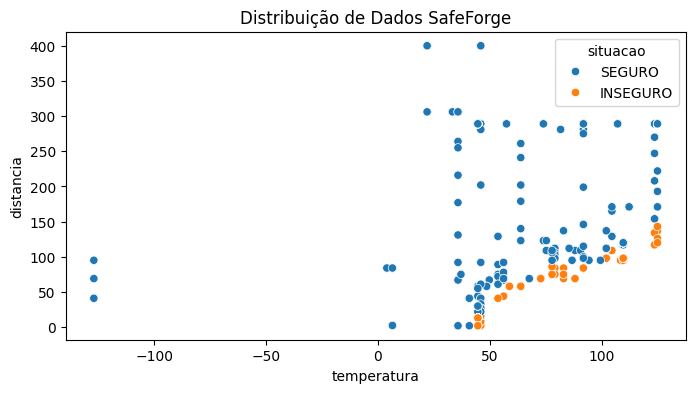

In [37]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='temperatura', y='distancia', hue='situacao')
plt.title('Distribuição de Dados SafeForge')
plt.show()

* **Histograma**
* Percebesse possiveis outliers ou ruidos.

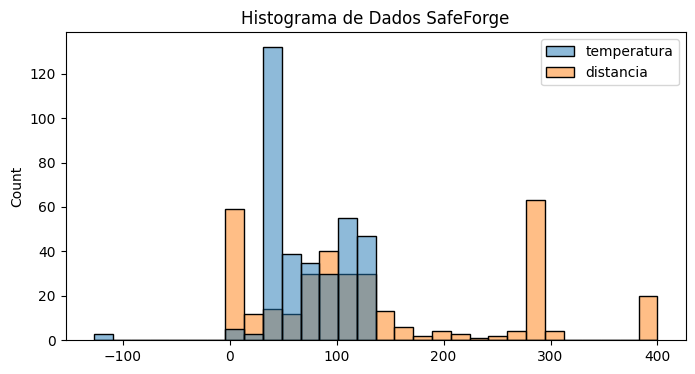

In [38]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df.drop('id', axis=1))
plt.title('Histograma de Dados SafeForge')
plt.show()

* **Grafico de boxplot**
* Neste grafico percebemos que existe outlier na feature temperatura.
* Isso também foi possivel perceber na analise descritiva, no minimo da temperatura que está -127.

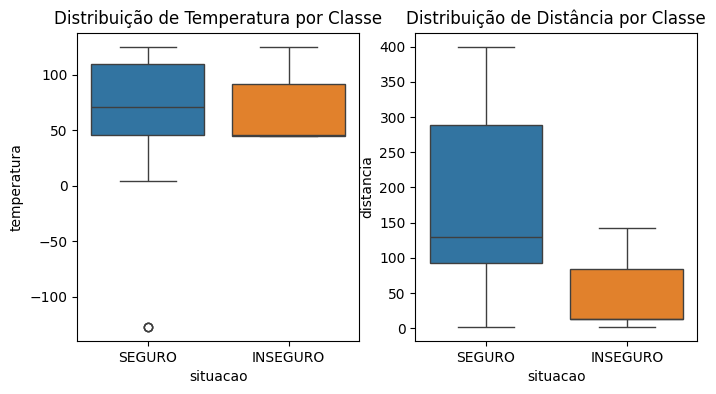

In [39]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='situacao', y='temperatura', hue='situacao')
plt.title('Distribuição de Temperatura por Classe')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='situacao', y='distancia', hue='situacao')
plt.title('Distribuição de Distância por Classe')
plt.show()

* Transformando a feature situacao em numerica e atribuino a nova feature chamada inseguro, que será o nosso target.

In [40]:
df['inseguro'] = df['situacao'].apply(lambda x: 1 if x == 'INSEGURO' else 0)
#Mostrando o resultado do nosso target
df[['situacao','inseguro']].drop_duplicates().head()

,situacao,inseguro
0,SEGURO,0
17,INSEGURO,1


* **Grafico de correlação.**
* Percebesse que existe uma correlação entre as features
* Uma correlação moderada negativa entre nossa target com a distancia.
* Também existe uma leve correlação positiva entre temperatura e distancia, mas podemos ignorar.

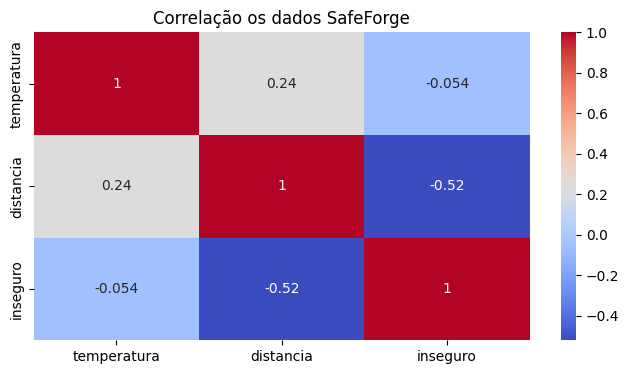

In [41]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.drop(['id','situacao'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlação os dados SafeForge')
plt.show()

* **Preparo dos dados**

In [42]:
#Separando as features do X e o target
X = df.drop(['id','situacao','inseguro'], axis=1)
y = df['inseguro']

#Separando os dados de treino e teste
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

#Este trecho foi corrigido após correção do professor
#Aplicando Scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

pd.DataFrame(x_train, columns=X.columns).head()

,temperatura,distancia
0,-0.917286,-0.621014
1,1.011950,-0.152275
2,1.011950,-0.178719
3,0.546614,-0.470399
4,-0.685401,-1.098420


* **Treinamento e Avaliação do Modelo**

In [43]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nFalsos Positivos (FP): {fp} (O modelo previu 'INSEGURO', mas era 'SEGURO')")
print(f"Falsos Negativos (FN): {fn} (O modelo previu 'SEGURO', mas era 'INSEGURO')")


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        51
           1       0.95      0.95      0.95        19

    accuracy                           0.97        70
   macro avg       0.96      0.96      0.96        70
weighted avg       0.97      0.97      0.97        70

0.9714285714285714

Falsos Positivos (FP): 1 (O modelo previu 'INSEGURO', mas era 'SEGURO')
Falsos Negativos (FN): 1 (O modelo previu 'SEGURO', mas era 'INSEGURO')
